<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Code_challenge.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>


## Regression MCQ
© ExploreAI Academy

In this MCQ, we will engage in a comprehensive multiple-choice exercise, applying regression concepts and techniques to agricultural yield prediction. Through a series of challenges, we'll analyse variable relationships, feature engineering, model construction, and evaluation, enhancing our understanding and proficiency in regression analysis.

# Learning objectives
By the end of this notebook, you should be able to:

* Analyse predictor variables and their relationship with the target variable.
* Perform feature engineering tasks, including encoding categorical variables and scaling features.
* Construct and evaluate multiple linear regression models using appropriate libraries.
* Identify and address multicollinearity issues using regularisation techniques such as LASSO and Ridge regression.
* Interpret regression coefficients and understand their impact on the target variable.
* Implement decision tree models for prediction tasks, exploring both categorical and numerical data
* Calculate and interpret MSE and RMSE for model evaluation.


# The data
Join us on an intriguing exploration of a vast agricultural dataset. Uncover the intricate connections between geographic, weather, soil, and farm management features, all leading to a prediction of yield. Our mission? To decode these relationships and empower farmers with actionable insights for improved productivity and informed decision-making.

## Data dictionary

**1. Geographic features**

- **Field_ID:** A unique identifier for each field (BigInt).
 
- **Elevation:** The elevation of the field above sea level in metres (Float).

- **Latitude:** Geographical latitude of the field in degrees (Float). (DUMMY VARIABLE- the simulation might have created a relationship)

- **Longitude:** Geographical longitude of the field in degrees (Float). (DUMMY VARIABLE- the simulation might have created a relationship)

- **Location:** Province the field is in (Text).

- **Slope:** The slope of the land in the field (Float).

**2. Weather features**

- **Rainfall:** Amount of rainfall in the area in mm (Float).

- **Min_temperature_C:** Average minimum temperature recorded in Celsius (Float).(DUMMY VARIABLE)

- **Max_temperature_C:** Average maximum temperature recorded in Celsius (Float).(DUMMY VARIABLE)

- **Ave_temps:** Average temperature in Celcius (Float).

**3. Soil and crop features**

- **Soil_fertility:** A measure of soil fertility where 0 is infertile soil, and 1 is very fertile soil (Float).

- **Soil_type:** Type of soil present in the field (Text).

- **pH:** pH level of the soil, which is a measure of how acidic/basic the soil is (Float).

**4. Farm management features**

- **Field_ID:** Corresponding field identifier (BigInt).

- **Pollution_level:** Level of pollution in the area where 0 is unpolluted and 1 is very polluted (Float).

- **Plot_size:** Size of the plot in the field (Ha) (Float). (DUMMY VARIABLE)

- **Chosen_crop:** Type of crop chosen for cultivation (Text).

- **Annual_yield:** Annual yield from the field (Float). This is the total output of the field. The field size and type of crop will affect the Annual Yield (DUMMY VARIABLE - Removed)

<br>

**5. Target variable**
- **Standard_yield:** Standardised yield expected from the field, normalised per crop (Float). This is independent of field size, or crop type. Multiplying this number by the field size, and average crop yield will give the Annual_Yield.

---

Let's import our database again, like we did last time. We won't use the weather data so it is commented out.

**Important:** Ensure that `data_ingestion.py` file and the `field_data_processor.py` files are stored in the same folder as your notebook, otherwise the data import will fail.
 
[Download files here](https://github.com/Explore-AI/Public-Data/raw/master/Maji_Ndogo/modules.zip)


In [130]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import statsmodels.graphics.correlation as sgc
from statsmodels.graphics.gofplots import qqplot
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import OLSInfluence
import seaborn as sns

In [131]:
# Read the database, and clean the data using the processing modules we built.

import re
import numpy as np
import pandas as pd
from field_data_processor import FieldDataProcessor
# from weather_data_processor import WeatherDataProcessor
import logging 

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

config_params = {
    "sql_query": """
            SELECT *
            FROM geographic_features
            LEFT JOIN weather_features USING (Field_ID)
            LEFT JOIN soil_and_crop_features USING (Field_ID)
            LEFT JOIN farm_management_features USING (Field_ID)
            """,
    "db_path": 'sqlite:///Maji_Ndogo_farm_survey_small.db',
    "columns_to_rename": {'Annual_yield': 'Crop_type', 'Crop_type': 'Annual_yield'},
    "values_to_rename": {'cassaval': 'cassava', 'wheatn': 'wheat', 'teaa': 'tea'},
    "weather_csv_path": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_station_data.csv",
    "weather_mapping_csv": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv",
    "regex_patterns" : {
            'Rainfall': r'(\d+(\.\d+)?)\s?mm',
            'Temperature': r'(\d+(\.\d+)?)\s?C',
            'Pollution_level': r'=\s*(-?\d+(\.\d+)?)|Pollution at \s*(-?\d+(\.\d+)?)'
            },
}
# Ignoring the field data for now.
field_processor = FieldDataProcessor(config_params)
field_processor.process()
field_df = field_processor.df

# We're not going to use the weather data this time, so we'll ignore it.
# weather_processor = WeatherDataProcessor(config_params)
# weather_processor.process()
# weather_df = weather_processor.weather_df

dataset = field_df.drop("Weather_station", axis=1)

2026-08-17 14:05:17,877 - data_ingestion - INFO - Database engine created successfully.
2026-08-17 14:05:17,985 - data_ingestion - INFO - Query executed successfully.
2026-08-17 14:05:17,986 - field_data_processor.FieldDataProcessor - INFO - Sucessfully loaded data.
2026-08-17 14:05:18,008 - field_data_processor.FieldDataProcessor - INFO - Swapped columns: Annual_yield with Crop_type
2026-08-17 14:05:18,942 - data_ingestion - INFO - CSV file read successfully from the web.


Before diving into our analysis, it's crucial to ensure the integrity of our dataset and that the data is still as we expect it to be.

In [132]:
# Validate the data
#!pip install pytest

dataset.to_csv('sampled_field_df.csv', index=False)

!pytest validate_data.py -v

import os# Define the file paths
field_csv_path = 'sampled_field_df.csv'

# Delete sampled_field_df.csv if it exists
if os.path.exists(field_csv_path):
    os.remove(field_csv_path)
    print(f"Deleted {field_csv_path}")
else:
    print(f"{field_csv_path} does not exist.")

============================= test session starts =============================
platform win32 -- Python 3.12.2, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\Anthony\Pictures\alX-datascience\machine_learning\notebooks\venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\Anthony\Pictures\alX-datascience\machine_learning\notebooks\week5
plugins: anyio-4.14.2, dash-4.4.0, cov-7.1.0, typeguard-4.5.2
collecting ... collected 4 items

validate_data.py::test_read_field_dataframe_shape PASSED                 [ 25%]
validate_data.py::test_field_dataframe_columns PASSED                    [ 50%]
validate_data.py::test_field_dataframe_non_negative_elevation PASSED     [ 75%]
validate_data.py::test_crop_types_are_valid PASSED                       [100%]

============================== 4 passed in 2.18s ==============================
Deleted sampled_field_df.csv


In [133]:
df = dataset.copy()
df.head()

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076


In [134]:
df.columns

Index(['Field_ID', 'Elevation', 'Latitude', 'Longitude', 'Location', 'Slope',
       'Rainfall', 'Min_temperature_C', 'Max_temperature_C', 'Ave_temps',
       'Soil_fertility', 'Soil_type', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop_type', 'Standard_yield'],
      dtype='object')

In [135]:
df.drop('Field_ID', axis=1, inplace=True)

## Challenge 1: Understanding our variables and variable selection
In this section, we will analyse the predictor variables in our dataset and how they relate to the target variable.

### Question 1
How many predictors do we originally have in our dataset, and which of these are categorical in nature?

**Hint**: The `Field_ID` serves as a unique identifier for each field and does not provide any predictive value for modeling.

#### Options
* 16 predictors; Location, Soil_type, and Crop_type are categorical.
* 18 predictors; Location, Soil_type, and Crop_type are categorical.
* 17 predictors; Location, Soil_type, and Crop_type are categorical.
* 16 predictors; Location, Soil_type, and Plot_size are categorical.

In [136]:
df_category = df.select_dtypes(include=['object']).copy()
df_numeric = df.select_dtypes(include=['number']).copy()

In [137]:
df_numeric.columns

Index(['Elevation', 'Latitude', 'Longitude', 'Slope', 'Rainfall',
       'Min_temperature_C', 'Max_temperature_C', 'Ave_temps', 'Soil_fertility',
       'pH', 'Pollution_level', 'Plot_size', 'Annual_yield', 'Standard_yield'],
      dtype='object')

In [138]:
df_category.columns

Index(['Location', 'Soil_type', 'Crop_type'], dtype='object')

In [139]:
# count columns in thedataset excluding the target variable(Standard_yield)
num_pred_features = df.drop('Standard_yield', axis=1).shape[1]
num_pred_features

16

## Answer

* 16 predictors are available: Location', 'Soil_type', 'Crop_type are Categorical

### Question 2
The categorical features in our dataset need to be converted into a format suitable for modeling. After applying dummy variable encoding to these categorical features, how many independent variables do we now have?

**Note**: Set the `drop_first` parameter to True.

**Hint**: Remember to exclude `Field_ID` 

#### Options
* 31
* 29
* 17
* 16

In [140]:
df_category.head()

,Location,Soil_type,Crop_type
0,Rural_Akatsi,Sandy,cassava
1,Rural_Sokoto,Volcanic,cassava
2,Rural_Sokoto,Volcanic,tea
3,Rural_Kilimani,Loamy,cassava
4,Rural_Kilimani,Sandy,wheat


In [141]:
df_dummy = pd.get_dummies(df, drop_first=True).astype('float64')

df_dummy.head()

,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,...,Soil_type_Sandy,Soil_type_Silt,Soil_type_Volcanic,Crop_type_cassava,Crop_type_coffee,Crop_type_maize,Crop_type_potato,Crop_type_rice,Crop_type_tea,Crop_type_wheat
0,786.05580,-7.389911,-7.556202,14.795113,1125.2,-3.1,33.1,15.00,0.62,6.169393,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,674.33410,-7.736849,-1.051539,11.374611,1450.7,-3.9,30.6,13.35,0.64,5.676648,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,826.53390,-9.926616,0.115156,11.339692,2208.9,-1.8,28.4,13.30,0.69,5.331993,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,574.94617,-2.420131,-6.592215,7.109855,328.8,-5.8,32.2,13.20,0.54,5.328150,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,886.35300,-3.055434,-7.952609,55.007656,785.2,-2.5,31.0,14.25,0.72,5.721234,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [142]:
df.shape

(5654, 17)

In [143]:
df_dummy.shape

(5654, 30)

In [144]:
df_dummy.columns

Index(['Elevation', 'Latitude', 'Longitude', 'Slope', 'Rainfall',
       'Min_temperature_C', 'Max_temperature_C', 'Ave_temps', 'Soil_fertility',
       'pH', 'Pollution_level', 'Plot_size', 'Annual_yield', 'Standard_yield',
       'Location_Rural_Amanzi', 'Location_Rural_Hawassa',
       'Location_Rural_Kilimani', 'Location_Rural_Sokoto', 'Soil_type_Peaty',
       'Soil_type_Rocky', 'Soil_type_Sandy', 'Soil_type_Silt',
       'Soil_type_Volcanic', 'Crop_type_cassava', 'Crop_type_coffee',
       'Crop_type_maize', 'Crop_type_potato', 'Crop_type_rice',
       'Crop_type_tea', 'Crop_type_wheat'],
      dtype='object')

In [145]:
df_dummy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5654 entries, 0 to 5653
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Elevation                5654 non-null   float64
 1   Latitude                 5654 non-null   float64
 2   Longitude                5654 non-null   float64
 3   Slope                    5654 non-null   float64
 4   Rainfall                 5654 non-null   float64
 5   Min_temperature_C        5654 non-null   float64
 6   Max_temperature_C        5654 non-null   float64
 7   Ave_temps                5654 non-null   float64
 8   Soil_fertility           5654 non-null   float64
 9   pH                       5654 non-null   float64
 10  Pollution_level          5654 non-null   float64
 11  Plot_size                5654 non-null   float64
 12  Annual_yield             5654 non-null   float64
 13  Standard_yield           5654 non-null   float64
 14  Location_Rural_Amanzi   

In [146]:
indp_vars = df_dummy.drop('Standard_yield', axis=1).shape[1]
indp_vars

29

## Answer
* For now we have 29 independent variables

### Question 3

From our encoded dataset, which variable has the third highest absolute correlation with the `Standard_yield`, excluding the variable itself?

#### Options
* Pollution_level
* Crop_type_tea
* Annual_yield 
* Longitude 

In [147]:
correlation_matrix = df_dummy.corr()['Standard_yield'].sort_values(ascending=False)
correlation_matrix

Standard_yield             1.000000
Crop_type_tea              0.432879
Soil_type_Volcanic         0.309982
Annual_yield               0.220812
Location_Rural_Sokoto      0.212337
Crop_type_potato           0.175484
Min_temperature_C          0.144233
Elevation                  0.129248
Crop_type_rice             0.104056
Longitude                  0.085343
Soil_fertility             0.070205
Latitude                   0.061724
Slope                      0.056991
Rainfall                   0.039217
Ave_temps                  0.006786
Crop_type_maize           -0.008100
Location_Rural_Kilimani   -0.014778
Plot_size                 -0.017014
Location_Rural_Amanzi     -0.032049
Soil_type_Rocky           -0.078355
Crop_type_wheat           -0.092420
Location_Rural_Hawassa    -0.110623
Max_temperature_C         -0.111649
Soil_type_Peaty           -0.135509
Soil_type_Sandy           -0.164714
Crop_type_cassava         -0.186716
pH                        -0.196613
Soil_type_Silt            -0

In [148]:
from scipy.stats import pearsonr

# Build a dictionary of correlation coefficients and p-values
dict_cp = {}

column_titles = [col for col in correlation_matrix.index if col!= 'Standard_yield']

for col in column_titles:
    p_val = round(pearsonr(df_dummy[col], df_dummy['Standard_yield'])[1],6)
    dict_cp[col] = {'Correlation_Coefficient':correlation_matrix[col],
                    'P_Value':p_val}
    
df_cp = pd.DataFrame(dict_cp).T
df_cp_sorted = df_cp.sort_values('P_Value')
df_cp_sorted[df_cp_sorted['P_Value']<0.05]

,Correlation_Coefficient,P_Value
Crop_type_tea,0.432879,0.000000
Soil_type_Volcanic,0.309982,0.000000
Annual_yield,0.220812,0.000000
Location_Rural_Sokoto,0.212337,0.000000
Crop_type_potato,0.175484,0.000000
Min_temperature_C,0.144233,0.000000
Elevation,0.129248,0.000000
Crop_type_rice,0.104056,0.000000
Longitude,0.085343,0.000000
Soil_fertility,0.070205,0.000000


In [149]:
df_cp

,Correlation_Coefficient,P_Value
Crop_type_tea,0.432879,0.000000
Soil_type_Volcanic,0.309982,0.000000
Annual_yield,0.220812,0.000000
Location_Rural_Sokoto,0.212337,0.000000
Crop_type_potato,0.175484,0.000000
Min_temperature_C,0.144233,0.000000
Elevation,0.129248,0.000000
Crop_type_rice,0.104056,0.000000
Longitude,0.085343,0.000000
Soil_fertility,0.070205,0.000000


## Answer
* Crop_tea_type has the highest correlation of 0.432879(43%)

### Question 4

In order to fit an ordinary least squares regression model to our encoded data we would need to make sure that all our variables are numeric. Through dummy variable encoding, we converted our categorical variables to multiple int/boolean variables (depending on the environment you are working on). The `sm.OLS()` method itself does not inherently handle boolean data types implicitly.

In most cases, when fitting a model with sm.OLS(), it's essential to ensure that all features are numeric. If boolean columns are present, they should be explicitly converted to numeric types before fitting the model.

Suppose our columns converted to boolean datatypes, which of the following statements is true after converting the boolean columns in the dataset to integer datatype?

* The boolean columns have been replaced with binary integer representations, with True converted to 1 and False converted to 0.
* The boolean columns have been removed from the dataset.
* The boolean columns have been replaced with binary integer representations, with True converted to 0 and False converted to 1.
* The boolean columns have been converted to a unique string datatype that is also an integer.

In [150]:
df_dummy.head()

,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,...,Soil_type_Sandy,Soil_type_Silt,Soil_type_Volcanic,Crop_type_cassava,Crop_type_coffee,Crop_type_maize,Crop_type_potato,Crop_type_rice,Crop_type_tea,Crop_type_wheat
0,786.05580,-7.389911,-7.556202,14.795113,1125.2,-3.1,33.1,15.00,0.62,6.169393,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,674.33410,-7.736849,-1.051539,11.374611,1450.7,-3.9,30.6,13.35,0.64,5.676648,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,826.53390,-9.926616,0.115156,11.339692,2208.9,-1.8,28.4,13.30,0.69,5.331993,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,574.94617,-2.420131,-6.592215,7.109855,328.8,-5.8,32.2,13.20,0.54,5.328150,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,886.35300,-3.055434,-7.952609,55.007656,785.2,-2.5,31.0,14.25,0.72,5.721234,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Answer

* The boolean columns have been replaced with binary integer representations, with True converted to 1 and False converted to 0.

### Question 5
Suppose we wish to determine which of the predictors in our dataset are statistically significant. We will follow the following steps:

* Fit a statsmodels regression model to predict `Standard_yield` using our encoded dataset.
* Extract p-values for each predictor from the fitted model to find the ones that are significant based on a given threshold.

Which of the following variables do we find to be statistically significant for predicting `Standard_yield`, based on a p-value threshold of 0.05 `(p-value < 0.05)`?

#### Options

* Slope
* Elevation
* pH
* Soil_fertility

In [151]:
correlation_matrix

Standard_yield             1.000000
Crop_type_tea              0.432879
Soil_type_Volcanic         0.309982
Annual_yield               0.220812
Location_Rural_Sokoto      0.212337
Crop_type_potato           0.175484
Min_temperature_C          0.144233
Elevation                  0.129248
Crop_type_rice             0.104056
Longitude                  0.085343
Soil_fertility             0.070205
Latitude                   0.061724
Slope                      0.056991
Rainfall                   0.039217
Ave_temps                  0.006786
Crop_type_maize           -0.008100
Location_Rural_Kilimani   -0.014778
Plot_size                 -0.017014
Location_Rural_Amanzi     -0.032049
Soil_type_Rocky           -0.078355
Crop_type_wheat           -0.092420
Location_Rural_Hawassa    -0.110623
Max_temperature_C         -0.111649
Soil_type_Peaty           -0.135509
Soil_type_Sandy           -0.164714
Crop_type_cassava         -0.186716
pH                        -0.196613
Soil_type_Silt            -0

In [152]:
from scipy.stats import shapiro, pearsonr

# getting the p-value using pearsonr function
dict_corr_p = {}
cols_title = [col for col in correlation_matrix.index if col!= 'Standard_yield']

for col in cols_title:
    p_val = round(pearsonr(df_dummy[col], df_dummy['Standard_yield'])[1],6)
    dict_corr_p[col] = {'Correlation_Coefficient':correlation_matrix[col],
                        'P_Value':p_val}

df_corr_p = pd.DataFrame(dict_corr_p).T
df_corr_p

,Correlation_Coefficient,P_Value
Crop_type_tea,0.432879,0.000000
Soil_type_Volcanic,0.309982,0.000000
Annual_yield,0.220812,0.000000
Location_Rural_Sokoto,0.212337,0.000000
Crop_type_potato,0.175484,0.000000
Min_temperature_C,0.144233,0.000000
Elevation,0.129248,0.000000
Crop_type_rice,0.104056,0.000000
Longitude,0.085343,0.000000
Soil_fertility,0.070205,0.000000


In [153]:
X = df_dummy.drop('Standard_yield', axis=1)
y = df_dummy['Standard_yield']

# Getting the statistical significance of the correlation coefficients using the p-values
x_names = df_corr_p[df_corr_p['P_Value']<0.05].index.tolist()
x_data = X[x_names]

In [154]:
X.shape, x_data.shape

((5654, 29), (5654, 25))

In [155]:
indep_corr = x_data.corr()
# indep_corr[indep_corr.abs() > 0.8]

row, col = np.where(indep_corr.abs() > 0.8)
off_diagonal = np.where(row != col)

indep_corr.iloc[row[off_diagonal], col[off_diagonal]]

,Elevation,Min_temperature_C
Min_temperature_C,0.956418,1.000000
Elevation,1.000000,0.956418


In [156]:
# dropping the highly correlated independent features ie Elevation
x_data.drop('Elevation', axis=1, inplace=True)

C:\Users\Anthony\AppData\Local\Temp\ipykernel_18504\232150760.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_data.drop('Elevation', axis=1, inplace=True)


In [157]:
# OLS fit
x_data_names = x_data.columns.tolist()

# y is a pandas Series; use its column name for a formula string
target_name = y.name if hasattr(y, 'name') and y.name else 'Standard_yield'
formula = target_name + ' ~ ' + ' + '.join(x_data_names)

print(f'Formula:\n\t {formula}')

Formula:
	 Standard_yield ~ Crop_type_tea + Soil_type_Volcanic + Annual_yield + Location_Rural_Sokoto + Crop_type_potato + Min_temperature_C + Crop_type_rice + Longitude + Soil_fertility + Latitude + Slope + Rainfall + Location_Rural_Amanzi + Soil_type_Rocky + Crop_type_wheat + Location_Rural_Hawassa + Max_temperature_C + Soil_type_Peaty + Soil_type_Sandy + Crop_type_cassava + pH + Soil_type_Silt + Crop_type_coffee + Pollution_level


In [158]:
from statsmodels.formula.api import ols

model = ols(formula=formula, data=df_dummy)
fitted_model = model.fit()

fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Standard_yield   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     404.3
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:05:26   Log-Likelihood:                 7198.3
No. Observations:                5654   AIC:                        -1.435e+04
Df Residuals:                    5629   BIC:                        -1.418e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.7581      0.157      4.825      0.000       0.450       1.066
Crop_type_tea              0.1410      0.004     34.775      0.000       0.133       0.149
Soil_type_Volcanic        -0.0829      0.005    -16.383      0.000      -0.093      -0.073
Annual_yield               0.0086      0.001     14.522      0.000       0.007       0.010
Location_Rural_Sokoto      0.0471      0.005      9.802      0.000       0.038       0.056
Crop_type_potato           0.0972      0.004     27.212      0.000       0.090       0.104
Min_temperature_C          0.0130      0.001      9.589      0.000       0.010       0.016
Crop_type_rice             0.1307      0.005     26.279      0.000       0.121       0.140
Longitude                 -0.0008      0.001     -1.068      0.286      -0.002       0.001
Soil_fertility            -0.5285      0.316     -1.674      0.094      -1.148       0.091
Latitude                  -0.0032      0.001     -4.019      0.000      -0.005      -0.002
Slope                      0.0026      0.001      2.672      0.008       0.001       0.005
Rainfall                4.274e-05   2.45e-05      1.745      0.081   -5.26e-06    9.07e-05
Location_Rural_Amanzi      0.0053      0.005      1.100      0.271      -0.004       0.015
Soil_type_Rocky           -0.1539      0.006    -25.668      0.000      -0.166      -0.142
Crop_type_wheat            0.0348      0.003     11.995      0.000       0.029       0.040
Location_Rural_Hawassa    -0.0089      0.003     -2.592      0.010      -0.016      -0.002
Max_temperature_C         -0.0005      0.001     -0.813      0.416      -0.002       0.001
Soil_type_Peaty           -0.1783      0.007    -26.687      0.000      -0.191      -0.165
Soil_type_Sandy           -0.1053      0.004    -29.051      0.000      -0.112      -0.098
Crop_type_cassava          0.0163      0.004      4.405      0.000       0.009       0.024
pH                         0.0265      0.002     15.278      0.000       0.023       0.030
Soil_type_Silt            -0.1651      0.005    -30.542      0.000      -0.176      -0.154
Crop_type_coffee          -0.0291      0.004     -8.005      0.000      -0.036      -0.022
Pollution_level           -0.2398      0.006    -43.556      0.000      -0.251      -0.229
==============================================================================
Omnibus:                       96.113   Durbin-Watson:                   1.952
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              102.332
Skew:                          -0.305   Prob(JB):                     6.01e-23
Kurtosis:                       3.250   Cond. No.                     5.08e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix

In [159]:
# 1. Convert the coefficients table into a DataFrame
results_df = pd.read_html(fitted_model.summary().tables[1].as_html(), header=0, index_col=0)[0]

# 2. Rename columns for absolute clarity
results_df.columns = ['Coefficient', 'Std Error', 't-Statistic', 'P-Value', 'Conf. Lower', 'Conf. Upper']

# 3. Apply a visual style to highlight significant variables (p <= 0.05)
def highlight_significant(val):
    return 'background-color: #d4edda; font-weight: bold;' if val <= 0.05 else ''

# Display the styled table in Jupyter Notebook
results_df.style.format("{:.4f}").map(highlight_significant, subset=['P-Value'])

C:\Users\Anthony\AppData\Local\Temp\ipykernel_18504\735478031.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  results_df = pd.read_html(fitted_model.summary().tables[1].as_html(), header=0, index_col=0)[0]


,Coefficient,Std Error,t-Statistic,P-Value,Conf. Lower,Conf. Upper
Intercept,0.7581,0.1570,4.8250,0.0000,0.4500,1.0660
Crop_type_tea,0.1410,0.0040,34.7750,0.0000,0.1330,0.1490
Soil_type_Volcanic,-0.0829,0.0050,-16.3830,0.0000,-0.0930,-0.0730
Annual_yield,0.0086,0.0010,14.5220,0.0000,0.0070,0.0100
Location_Rural_Sokoto,0.0471,0.0050,9.8020,0.0000,0.0380,0.0560
Crop_type_potato,0.0972,0.0040,27.2120,0.0000,0.0900,0.1040
Min_temperature_C,0.0130,0.0010,9.5890,0.0000,0.0100,0.0160
Crop_type_rice,0.1307,0.0050,26.2790,0.0000,0.1210,0.1400
Longitude,-0.0008,0.0010,-1.0680,0.2860,-0.0020,0.0010
Soil_fertility,-0.5285,0.3160,-1.6740,0.0940,-1.1480,0.0910


## Challenge 2: Generating a multiple linear regression model

After encoding our variables and performing preliminary analysis, let's continue our efforts to identify the variables that will enable us to construct the most accurate multiple linear regression model possible with the data that we have.

### Question 6
Create a correlation matrix using all the columns in our encoded dataset and display it as a heatmap.<br>

Which of the following independent variables have a strong correlation with one another.

* Plot_size and Crop_type_tea
* Pollution_level and Soil_type_Rocky
* Crop_type_cassava and Soil_type_Sandy
* Min_temperature_C and Elevation

In [160]:
# Create the correlation_matrix
# df_new_dummy = pd.concat([x_data, y], axis=1)
df_new_dummy = df_dummy.copy()
df_new_dummy.head()

,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,...,Soil_type_Sandy,Soil_type_Silt,Soil_type_Volcanic,Crop_type_cassava,Crop_type_coffee,Crop_type_maize,Crop_type_potato,Crop_type_rice,Crop_type_tea,Crop_type_wheat
0,786.05580,-7.389911,-7.556202,14.795113,1125.2,-3.1,33.1,15.00,0.62,6.169393,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,674.33410,-7.736849,-1.051539,11.374611,1450.7,-3.9,30.6,13.35,0.64,5.676648,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,826.53390,-9.926616,0.115156,11.339692,2208.9,-1.8,28.4,13.30,0.69,5.331993,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,574.94617,-2.420131,-6.592215,7.109855,328.8,-5.8,32.2,13.20,0.54,5.328150,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,886.35300,-3.055434,-7.952609,55.007656,785.2,-2.5,31.0,14.25,0.72,5.721234,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [161]:
df_new_dummy.shape

(5654, 30)

In [ ]:
correlation_matrix = df_new_dummy.corr()
correlation_matrix

,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,...,Soil_type_Sandy,Soil_type_Silt,Soil_type_Volcanic,Crop_type_cassava,Crop_type_coffee,Crop_type_maize,Crop_type_potato,Crop_type_rice,Crop_type_tea,Crop_type_wheat
Elevation,1.000000,0.546737,0.345139,0.081837,-0.238518,0.956418,-0.605884,0.203061,-0.146844,-0.430787,...,0.376316,-0.677504,0.361268,0.095462,0.018497,0.067961,0.139176,-0.364053,0.347454,-0.134849
Latitude,0.546737,1.000000,0.257728,0.103381,-0.756442,0.337544,-0.340948,-0.077763,-0.566838,-0.220201,...,0.376229,-0.643981,-0.070117,0.050678,-0.125878,0.199797,0.331657,-0.294085,-0.002533,0.072679
Longitude,0.345139,0.257728,1.000000,-0.078865,0.146665,0.398923,-0.223253,0.119329,0.071705,-0.315035,...,-0.143360,-0.385025,0.489112,0.127606,0.047481,-0.057610,-0.106242,-0.180279,0.320515,-0.110908
Slope,0.081837,0.103381,-0.078865,1.000000,-0.131472,0.044370,-0.046567,-0.012279,0.550326,-0.087969,...,0.139921,-0.032525,-0.049896,-0.047826,-0.040313,0.022273,0.091620,-0.022758,0.024905,0.012189
Rainfall,-0.238518,-0.756442,0.146665,-0.131472,1.000000,0.052469,0.155806,0.233366,0.752914,0.025182,...,-0.500037,0.512560,0.475378,0.006320,0.225761,-0.287236,-0.447364,0.191002,0.292034,-0.213953
Min_temperature_C,0.956418,0.337544,0.398923,0.044370,0.052469,1.000000,-0.576769,0.278994,0.072797,-0.435366,...,0.237812,-0.543804,0.512421,0.100505,0.086790,-0.015453,0.009852,-0.317787,0.443157,-0.202232
Max_temperature_C,-0.605884,-0.340948,-0.223253,-0.046567,0.155806,-0.576769,1.000000,0.623555,0.099502,0.255306,...,-0.223547,0.423341,-0.225632,0.008833,-0.000344,-0.040994,-0.121873,0.220058,-0.211131,0.034573
Ave_temps,0.203061,-0.077763,0.119329,-0.012279,0.233366,0.278994,0.623555,1.000000,0.186633,-0.116527,...,-0.035200,-0.022773,0.225150,0.106567,0.082654,-0.062978,-0.133836,-0.045439,0.175911,-0.152894
Soil_fertility,-0.146844,-0.566838,0.071705,0.550326,0.752914,0.072797,0.099502,0.186633,1.000000,-0.035415,...,-0.326256,0.409878,0.366181,-0.027643,0.163027,-0.226270,-0.315786,0.144676,0.261981,-0.171082
pH,-0.430787,-0.220201,-0.315035,-0.087969,0.025182,-0.435366,0.255306,-0.116527,-0.035415,1.000000,...,0.035838,0.535893,-0.486016,-0.202740,0.203351,0.126780,-0.081037,0.133934,-0.514695,0.245135


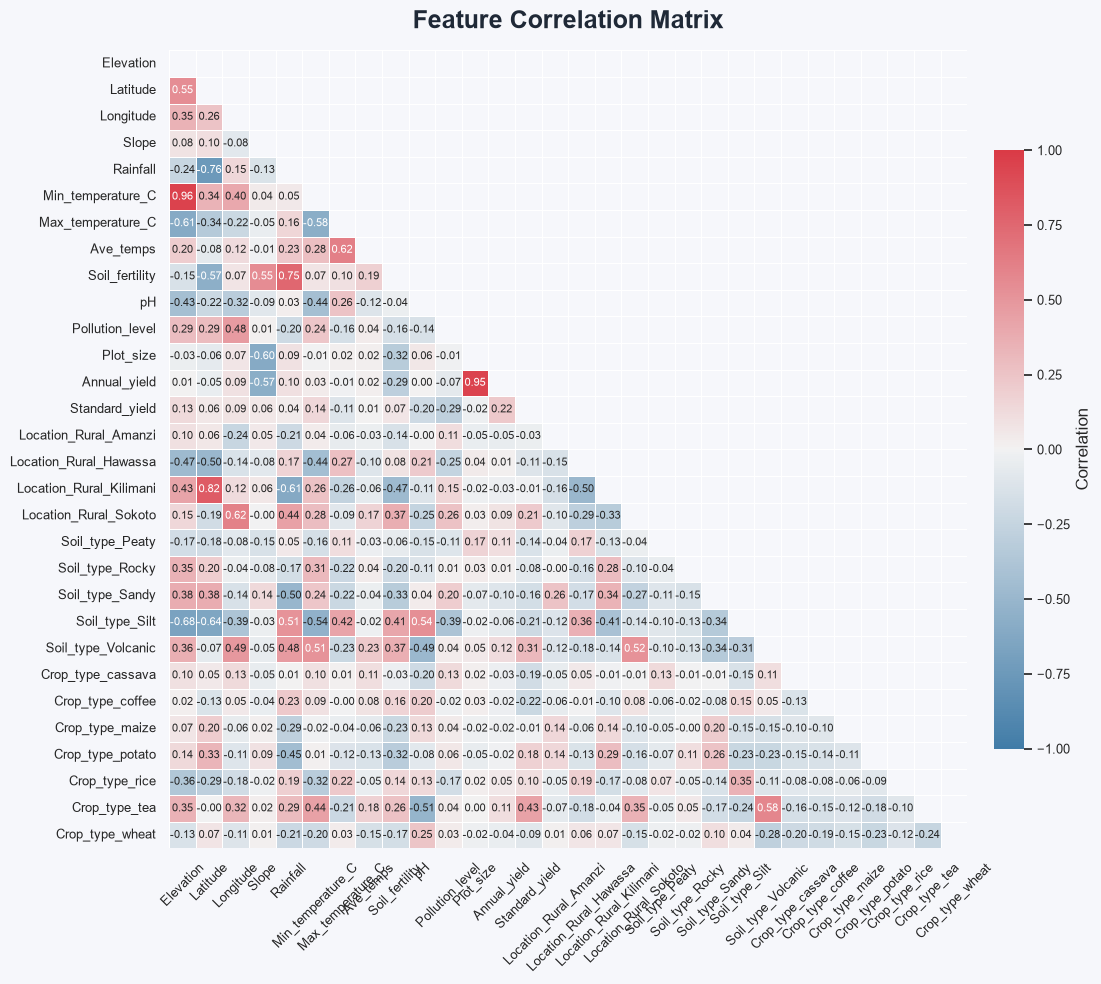

In [163]:
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(14, 10), facecolor="#f6f7fb")
ax.set_facecolor("#f6f7fb")

# Show only one triangle to reduce clutter and focus attention
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
cmap = sns.diverging_palette(240, 10, as_cmap=True)

heat = sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.75, "pad": 0.02, "label": "Correlation"},
    annot_kws={"size": 8},
    ax=ax,
)

ax.set_title("Feature Correlation Matrix", fontsize=18, fontweight="bold", pad=16, color="#1f2937")
ax.tick_params(axis="x", labelrotation=45, labelsize=9)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)

cbar = heat.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

In [164]:
# Keep a matrix-style view of strong correlations only
abs_corr = correlation_matrix.abs()

# Keep values > 0.5; others become NaN first, then 0 to preserve current display style
highest_corr_matrix = abs_corr.where(abs_corr > 0.5).fillna(0)

# Optional: hide self-correlation diagonal
np.fill_diagonal(highest_corr_matrix.values, 0)

highest_corr_matrix.round(2)

,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,...,Soil_type_Sandy,Soil_type_Silt,Soil_type_Volcanic,Crop_type_cassava,Crop_type_coffee,Crop_type_maize,Crop_type_potato,Crop_type_rice,Crop_type_tea,Crop_type_wheat
Elevation,0.00,0.55,0.00,0.00,0.00,0.96,0.61,0.00,0.00,0.00,...,0.0,0.68,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
Latitude,0.55,0.00,0.00,0.00,0.76,0.00,0.00,0.00,0.57,0.00,...,0.0,0.64,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
Longitude,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
Slope,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.55,0.00,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
Rainfall,0.00,0.76,0.00,0.00,0.00,0.00,0.00,0.00,0.75,0.00,...,0.5,0.51,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
Min_temperature_C,0.96,0.00,0.00,0.00,0.00,0.00,0.58,0.00,0.00,0.00,...,0.0,0.54,0.51,0.0,0.0,0.0,0.0,0.0,0.00,0.0
Max_temperature_C,0.61,0.00,0.00,0.00,0.00,0.58,0.00,0.62,0.00,0.00,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
Ave_temps,0.00,0.00,0.00,0.00,0.00,0.00,0.62,0.00,0.00,0.00,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
Soil_fertility,0.00,0.57,0.00,0.55,0.75,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
pH,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.54,0.00,0.0,0.0,0.0,0.0,0.0,0.51,0.0


In [165]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [166]:
target_name

'Standard_yield'

In [167]:
x_data_names

['Crop_type_tea',
 'Soil_type_Volcanic',
 'Annual_yield',
 'Location_Rural_Sokoto',
 'Crop_type_potato',
 'Min_temperature_C',
 'Crop_type_rice',
 'Longitude',
 'Soil_fertility',
 'Latitude',
 'Slope',
 'Rainfall',
 'Location_Rural_Amanzi',
 'Soil_type_Rocky',
 'Crop_type_wheat',
 'Location_Rural_Hawassa',
 'Max_temperature_C',
 'Soil_type_Peaty',
 'Soil_type_Sandy',
 'Crop_type_cassava',
 'pH',
 'Soil_type_Silt',
 'Crop_type_coffee',
 'Pollution_level']

In [168]:
X = df_dummy[x_data_names]
y = df_dummy[target_name]

In [169]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [170]:
lm = LinearRegression()
lm.fit(X_train, y_train)

train_standard_yield_pred = lm.predict(X_train)
test_standard_yield_pred = lm.predict(X_test)

In [171]:
# Evaluate the model
train_mse = mean_squared_error(y_train, train_standard_yield_pred)
train_r2 = r2_score(y_train, train_standard_yield_pred)
train_rmse = np.sqrt(train_mse)
test_mse = mean_squared_error(y_test, test_standard_yield_pred)
test_r2 = r2_score(y_test, test_standard_yield_pred)
test_rmse = np.sqrt(test_mse)


df_results = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'R-squared'],
    'Train': [train_mse, train_rmse, train_r2],
    'Test': [test_mse, test_rmse, test_r2]
})

df_results

,Metric,Train,Test
0,MSE,0.004600,0.004574
1,RMSE,0.067823,0.067630
2,R-squared,0.625444,0.656762


## Answer

* Min_temperature_C and Crop_type_Cassava are highly correlated

### Question 7
Now that we have analysed our variables, let's fit an ordinary least squares regression model using `statsmodels.formula.api` and then print the model summary. Construct the model using all the independent variables in our encoded dataset (excuding `Field_ID`).<br>

Which of the following statements accurately describes the interpretation of the F-statistic in the context of our regression model?

#### Options
* The F-statistic tests the overall significance of the regression model. A low F-statistic value with a corresponding high p-value  indicates that the regression model is statistically significant, meaning that at least one of the independent variables has a significant effect on the dependent variable.
* The F-statistic tests the overall significance of the regression model. A high F-statistic value with a corresponding low p-value indicates that the regression model is statistically significant, meaning that at least one of the independent variables has a significant effect on the dependent variable.
* The F-statistic tests the overall significance of the regression model. A high F-statistic value with a corresponding high p-value indicates that the regression model is statistically significant, meaning that at least one of the independent variables has a significant effect on the dependent variable.
* The F-statistic tests the overall significance of the regression model. A low F-statistic value with a corresponding low p-value  indicates that the regression model is not statistically significant, meaning that none of the independent variables have a significant effect on the dependent variable.

In [172]:
fitted_model.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,0.758139,0.157139,4.824646,1.439508e-06,0.450086,1.066192
Crop_type_tea,0.141032,0.004056,34.774896,3.395626e-240,0.133082,0.148983
Soil_type_Volcanic,-0.082926,0.005062,-16.383487,5.710731e-59,-0.092848,-0.073003
Annual_yield,0.008584,0.000591,14.521963,6.154675e-47,0.007425,0.009743
Location_Rural_Sokoto,0.047083,0.004803,9.801827,1.672336e-22,0.037666,0.056500
Crop_type_potato,0.097163,0.003571,27.212397,2.660016e-153,0.090164,0.104163
Min_temperature_C,0.012959,0.001351,9.589326,1.295925e-21,0.010310,0.015608
Crop_type_rice,0.130730,0.004975,26.279117,1.138304e-143,0.120977,0.140482
Longitude,-0.000794,0.000744,-1.067511,2.857869e-01,-0.002253,0.000664
Soil_fertility,-0.528505,0.315785,-1.673621,9.426062e-02,-1.147565,0.090556


### Question 8 

This summary  gives us an indication of possible multicollinearity present within our predictor variables. The presence of any correlation among predictors is detrimental to model quality because it tends to increase the standard error of the coefficients and it becomes difficult to estimate the effect of any one predictor variable on the response variable.

To avoid this, let's reduce the number of independent variables included in our model.
Fit the model using the following variables:<br>

* `Pollution_level` 
* `Crop_type_coffee` 
* `Crop_type_tea`
* `Location_Rural_Sokoto`
* `Annual_yield` 
* `Soil_type_Silt`
* `Soil_type_Volcanic`

After reducing the number of dependent variables accordingly, how did the model change?

#### Options:

* The model worsened.
* The model improved.
* The model remained unchanged.
* It cannot be determined from the given information.

In [173]:
columns = [
    "Pollution_level", 
    "Crop_type_coffee", 
    "Crop_type_tea",
    "Location_Rural_Sokoto",
    "Annual_yield", 
    "Soil_type_Silt",
    "Soil_type_Volcanic"
]

df_selected = df_dummy[columns + ['Standard_yield']]

df_selected.head()

,Pollution_level,Crop_type_coffee,Crop_type_tea,Location_Rural_Sokoto,Annual_yield,Soil_type_Silt,Soil_type_Volcanic,Standard_yield
0,0.085267,0.0,0.0,0.0,0.751354,0.0,0.0,0.577964
1,0.399684,0.0,0.0,1.0,1.069865,0.0,1.0,0.486302
2,0.358029,0.0,1.0,1.0,2.208801,0.0,1.0,0.649647
3,0.286687,0.0,0.0,0.0,1.277635,0.0,0.0,0.532348
4,0.043190,0.0,0.0,0.0,0.832614,0.0,0.0,0.555076


In [174]:
y_selected = df_selected['Standard_yield']
X_selected = df_selected.drop('Standard_yield', axis=1)

In [175]:
selected_formula = y_selected.name + ' ~ ' + ' + '.join(X_selected.columns.tolist())

print(f'Selected Formula:\n\t {selected_formula}')

Selected Formula:
	 Standard_yield ~ Pollution_level + Crop_type_coffee + Crop_type_tea + Location_Rural_Sokoto + Annual_yield + Soil_type_Silt + Soil_type_Volcanic


In [176]:
selected_model = ols(formula=selected_formula, data=df_selected)

fitted_selected_model = selected_model.fit()

fitted_selected_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Standard_yield   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     552.1
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:05:29   Log-Likelihood:                 5839.8
No. Observations:                5654   AIC:                        -1.166e+04
Df Residuals:                    5646   BIC:                        -1.161e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.5690      0.003    212.947      0.000       0.564       0.574
Pollution_level          -0.2237      0.006    -37.672      0.000      -0.235      -0.212
Crop_type_coffee         -0.0556      0.004    -14.370      0.000      -0.063      -0.048
Crop_type_tea             0.0931      0.004     23.626      0.000       0.085       0.101
Location_Rural_Sokoto     0.0647      0.004     16.768      0.000       0.057       0.072
Annual_yield              0.0071      0.001     11.824      0.000       0.006       0.008
Soil_type_Silt           -0.0693      0.003    -21.619      0.000      -0.076      -0.063
Soil_type_Volcanic       -0.0127      0.004     -3.288      0.001      -0.020      -0.005
==============================================================================
Omnibus:                      111.561   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              117.254
Skew:                          -0.348   Prob(JB):                     3.46e-26
Kurtosis:                       2.880   Cond. No.                         17.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Answer

* The Model Worsened

### Question 9
Let's evaluate our model's results. Generate a scatter plot of the residuals against the fitted values allowing us to visually inspect whether the residuals have constant variance and are distributed randomly around the zero residual line.

What does the scatter plot tell us?

#### Options

* The model has perfect predictive accuracy.
* The plot indicates homoscedasticity as residuals have a constant variance and are distributed randomly around the zero residual line.
* There is no linear relationship between the dependent and independent variables.
* The model suffers from multicollinearity.

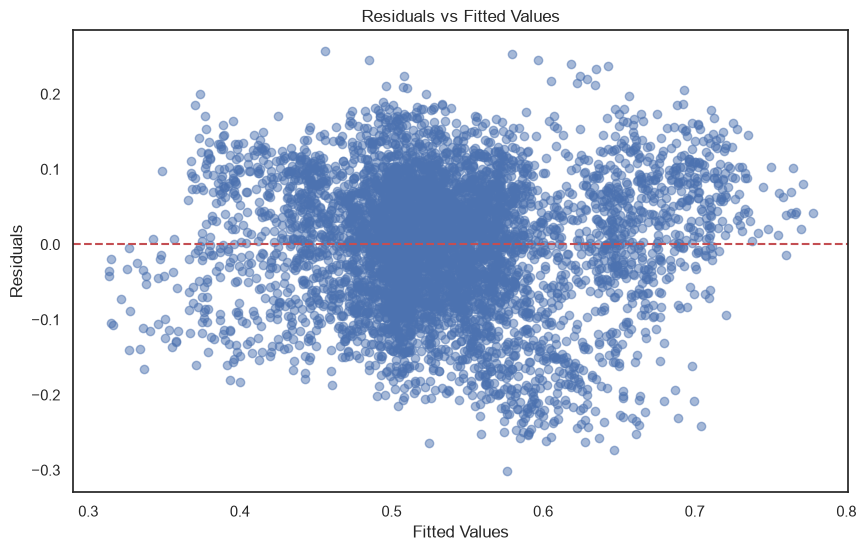

In [177]:
# Residuals
y_selected_pred = fitted_selected_model.predict(X_selected)
residuals_selected = y_selected - y_selected_pred


# Scatter plot of residuals vs fitted values
plt.figure(figsize=(10, 6))
plt.scatter(y_selected_pred, residuals_selected, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Answer

* The plot indicates homoscedasticity as residuals have a constant variance and are distributed randomly around the zero residual line.

### Question 10
If a linear regression model indicated heteroscedasticity, which of the following actions could be considered to address this issue?

* Applying transformations to the independent variables to better fit the linear relationship.
* Implementing weighted least squares regression to give less emphasis to observations with higher variance in residuals.
* Removing outliers from the dataset to reduce the impact of extreme values on the variance of residuals.
* All of the above.

In [178]:
lm = LinearRegression()


model_selected = lm.fit(X_selected, y_selected)

lm_selected_pred = model_selected.predict(X_selected)

lm_selected_residuals = y_selected - lm_selected_pred

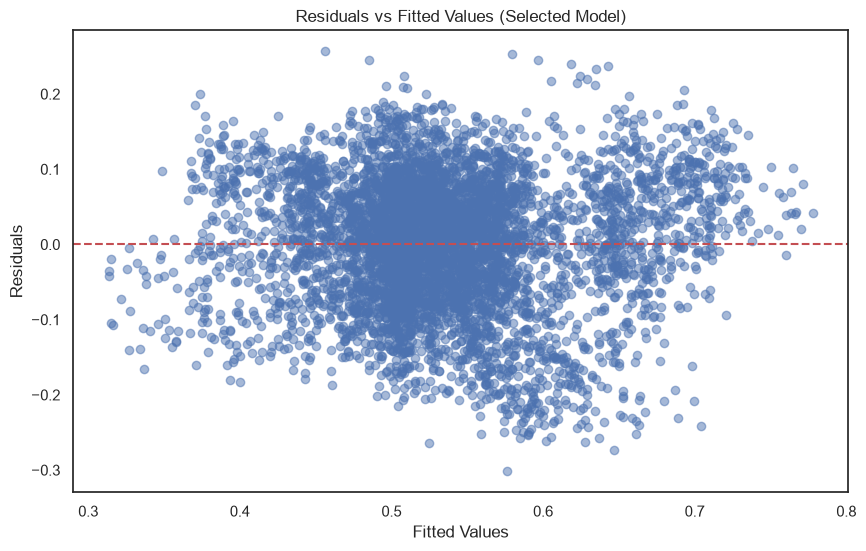

In [179]:
# Scatter plot of residuals vs fitted values
plt.figure(figsize=(10, 6))
plt.scatter(lm_selected_pred, lm_selected_residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values (Selected Model)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Answer

All the above

## Challenge 3: Using regularisation to optimise agricultural yield

Continuing with our task, after fitting our model, we decide to go back to the drawing board to explore more ways to implement feature engineering and data pre-processing in order to optimise our model. We suspect that, if we use all the variables available to us, the model might overfit due to the high dimensionality of the data. Regularisation techniques will therefore be critical in building a predictive model that generalises well to new, unseen data.

### Question 11
Our first step in the feature engineering involves creating a new feature, `Temperature_Range`, and scaling features using `StandardScaler`. The difference between `Min_temperature_C` and `Max_temperature_C` is the temperature range.

Given the code block below, which option correctly completes the feature engineering step of creating the `Temperature_Range` column?

**Hint**: Insert the correct code snippet into the appropriate location within the code block to run it.

#### Options:

* `dataset['Temperature_Range'] = dataset[['Min_temperature_C','Max_temperature_C']].min(axis=1)`
* `dataset['Temperature_Range'] = dataset['Max_temperature_C'] - dataset['Min_temperature_C']`
* `dataset = dataset.assign(Temperature_Range = dataset['Max_temperature'] - dataset['Min_temperature'])`
* `dataset[['Temperature_Range']] = dataset[['Max_temperature_C']] - dataset[['Min_temperature_C']]`



In [180]:
df2 = dataset.copy()
df2.head()

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076


In [181]:
df2.columns

Index(['Field_ID', 'Elevation', 'Latitude', 'Longitude', 'Location', 'Slope',
       'Rainfall', 'Min_temperature_C', 'Max_temperature_C', 'Ave_temps',
       'Soil_fertility', 'Soil_type', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop_type', 'Standard_yield'],
      dtype='object')

In [182]:
from sklearn.preprocessing import StandardScaler

# Insert selected option here
df2['Temperature_Range'] = df2['Max_temperature_C'] - df2['Min_temperature_C']

# Select features for scaling (exclude non-numeric or target variables)
features = ['Elevation', 'Slope', 'Rainfall', 'Ave_temps', 'Temperature_Range', 'Soil_fertility', 'pH', 'Pollution_level']

y_feature = df2['Standard_yield']
x_feature = features

# Initialise StandardScaler and apply it to the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df2[x_feature])

# Show the first 5 rows of the scaled features
print(scaled_features[:5])

[[ 0.85426539  0.31997088 -0.15356676  2.21747303  0.30626766  0.01544079
   0.71256827 -0.61634976]
 [ 0.21055364 -0.03858151  0.49777372  0.15900087 -0.25298298  0.4619994
   0.08816394  0.7886906 ]
 [ 1.08748981 -0.04224188  2.01496684  0.09662293 -1.66755812  1.57839593
  -0.34858051  0.60254524]
 [-0.3620941  -0.4856324  -1.74719984 -0.02813296  0.8984154  -1.77079366
  -0.35345077  0.28374058]
 [ 1.43215211  4.53523034 -0.83392242  1.28180387 -0.58195394  2.24823384
   0.14466333 -0.80437805]]


# Answer

* df2['Temperature_Range'] = df2['Max_temperature_C'] - df2['Min_temperature_C']

### Question 12


Consider a scenario where we decide to employ LASSO regression to identify predictive features associated with our dependent variable.

We implement the Python code block provided below.

What is the purpose of the `LassoCV(cv=5)` constructor parameter `cv=5`?

#### Options:

* It indicates that 5-fold cross-validation should be used to select the best regularisation parameter.
* It sets the penalty coefficient to 5, increasing the regularisation strength.
* It specifies that the LASSO model should use a 5-degree polynomial feature expansion.
* It defines that the model should only select 5 features at most.

In [183]:
from sklearn.linear_model import LassoCV

# scaled_features is our matrix of scaled features and dataset['Standard_yield'] is the target variable
lasso = LassoCV(cv=5).fit(scaled_features, df2['Standard_yield'])

# Find the features with non-zero coefficients
selected_features = [x_feature[i] for i, coef in enumerate(lasso.coef_) if coef != 0]

print("Selected features:", selected_features)

Selected features: ['Elevation', 'Slope', 'Rainfall', 'Ave_temps', 'Temperature_Range', 'pH', 'Pollution_level']


In [184]:
lasso_fit = lasso

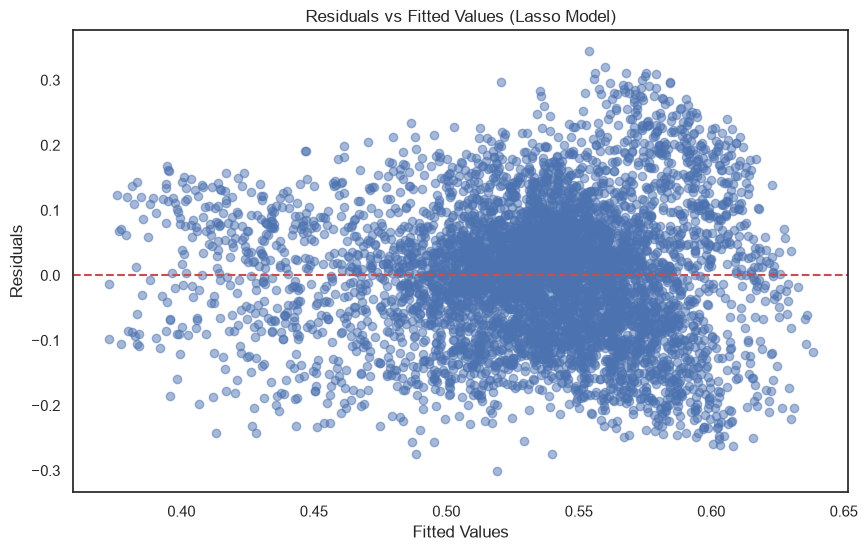

In [185]:
lasso_pred = lasso_fit.predict(scaled_features)
lasso_residuals = y_feature - lasso_pred


# Scatter plot of residuals vs fitted values
plt.figure(figsize=(10, 6))
plt.scatter(lasso_pred, lasso_residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values (Lasso Model)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

In [186]:
# Metrics for Lasso Model
lasso_mse = mean_squared_error(y_feature, lasso_pred)
lasso_r2 = r2_score(y_feature, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_rss = np.sum(lasso_residuals ** 2)

lasso_metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'R-squared', 'RSS'],
    'Value': [lasso_mse, lasso_rmse, lasso_r2, lasso_rss]
})

lasso_metrics

,Metric,Value
0,MSE,0.010506
1,RMSE,0.102500
2,R-squared,0.159389
3,RSS,59.402254


# Answer

* It indicates that 5-fold cross-validation should be used to select the best regularisation parameter.

### Question 13

In trying to address multicollinearity in our dataset, we also decide to implement Ridge regression. After understanding that Ridge regression applies an L2 penalty to the coefficients to reduce their magnitude without setting them to zero, we decide to use `RidgeCV` for applying Ridge regression with cross-validation to select the optimal penalty strength. Given the snippet of code below, which parameter correctly adjusts the strength of the regularisation applied to the model?

**Hint**: Insert the correct code snippet into the appropriate location within the code block to run it.

#### Options:
* `cv=[0.001, 0.01, 0.1, 1, 10, 100]`
* `fit_intercept=True`
* `alphas=[0.001, 0.01, 0.1, 1, 10, 100]`
* `scoring='neg_mean_squared_error`

In [187]:
from sklearn.linear_model import RidgeCV

# Insert selected option here
alphas=[0.001, 0.01, 0.1, 1, 10, 100]

# Apply Ridge regression with cross-validation
ridge = RidgeCV(alphas=alphas, cv=5).fit(scaled_features, y_feature)

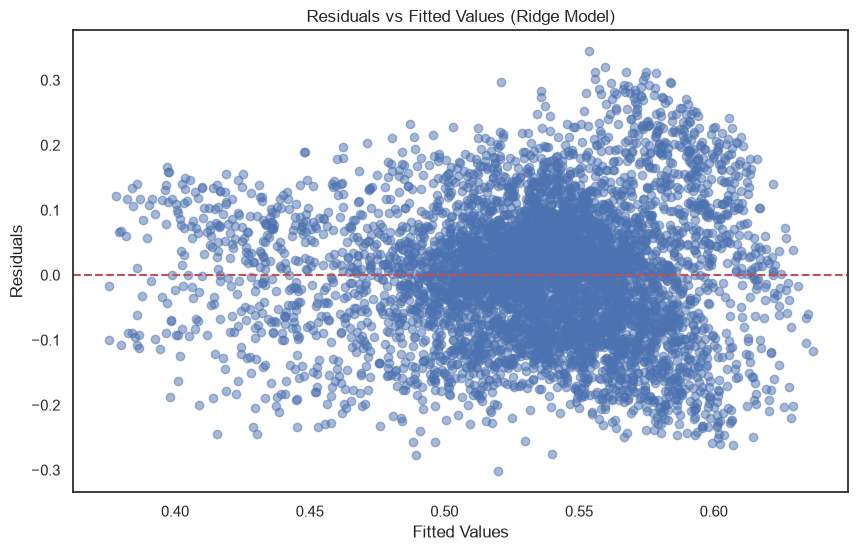

In [188]:
ridge_pred = ridge.predict(scaled_features)
ridge_residuals = y_feature - ridge_pred

# Scatter plot of residuals vs fitted values
plt.figure(figsize=(10, 6))
plt.scatter(ridge_pred, ridge_residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values (Ridge Model)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

In [189]:
# Ridge Model Metrics
ridge_mse = mean_squared_error(y_feature, ridge_pred)
ridge_r2 = r2_score(y_feature, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_rss = np.sum(ridge_residuals ** 2)

ridge_metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'R-squared', 'RSS'],
    'Value': [ridge_mse, ridge_rmse, ridge_r2, ridge_rss]
})

ridge_metrics

,Metric,Value
0,MSE,0.010507
1,RMSE,0.102503
2,R-squared,0.159334
3,RSS,59.406137


# Answer

* alphas=[0.001, 0.01, 0.1, 1, 10, 100]

### Question 14

Given our dataset includes variables such as `Elevation` and `Slope`, and considering the potential interactions between these variables might impact crop yield, we aim to capture both these interactions and possible non-linear relationships. Which of the following methods is specifically designed to create a quadratic interaction term without including an intercept in the feature set?

**HINT:** Consider utilising `sklearn`'s feature transformation tools for this purpose.

* `poly = PolynomialFeatures(degree=2, include_bias=False)` 
* `poly = PolynomialFeatures(degree=1, include_bias=False)` 
* `poly = PolynomialFeatures(degree=3, include_bias=True)` 
* `poly = PolynomialFeatures(degree=2, include_bias=True)`

In [190]:
from sklearn.preprocessing import PolynomialFeatures

# Generate polynomial and interaction features
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)

poly_features = poly.fit_transform(dataset[['Elevation', 'Slope']])

# Display the shape of the new feature matrix
poly_features.shape

(5654, 5)

In [191]:
poly_features

array([[7.86055800e+02, 1.47951130e+01, 6.17883721e+05, 1.16297844e+04,
        2.18895369e+02],
       [6.74334100e+02, 1.13746110e+01, 4.54726478e+05, 7.67028807e+03,
        1.29381775e+02],
       [8.26533900e+02, 1.13396920e+01, 6.83158288e+05, 9.37263985e+03,
        1.28588615e+02],
       ...,
       [6.70779000e+02, 7.63647000e+00, 4.49944467e+05, 5.12238371e+03,
        5.83156741e+01],
       [4.29488400e+02, 1.39447200e+01, 1.84460286e+05, 5.98909548e+03,
        1.94455216e+02],
       [7.63090300e+02, 3.51894300e+01, 5.82306806e+05, 2.68527127e+04,
        1.23829598e+03]], shape=(5654, 5))

In [192]:
poly_feature_names = poly.get_feature_names_out(['Elevation', 'Slope'])
poly_feature_names

array(['Elevation', 'Slope', 'Elevation^2', 'Elevation Slope', 'Slope^2'],
      dtype=object)

### Question 15

After implementing Ridge regression to address multicollinearity and prevent overfitting in our model we need to interpret the coefficients to understand the impact of each feature on the standard yield.

Based on the output of the Ridge regression coefficients in the code block below, which statement is true regarding the impact of each feature on the standard yield?

#### Options:

* Feature 1 has the highest positive impact, followed by Feature 2 and Feature 3.
* Feature 3 has the highest positive impact, followed by Feature 1 and Feature 2.
* The coefficients are inconclusive; further analysis is needed to determine the impact of each feature.
* Feature 2 has the highest positive impact, while Feature 3 and Feature 1 have negative impacts.

In [193]:
from sklearn.linear_model import Ridge
import numpy as np

# Assuming `X` is the feature matrix and `y` is the target variable
X = np.array([[0.5, 0.2, 0.1],
              [0.9, 0.3, 0.5],
              [0.3, 0.8, 0.2]])
y = np.array([0.7, 0.6, 0.8])

# Fit Ridge regression model with alpha = 0.1
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X, y)

# Display the coefficients of the model
ridge_model.coef_, ridge_model.intercept_


(array([-0.13661379,  0.10262221, -0.07348657]),
 np.float64(0.7525412754936871))

# Answer

* Feature 2 has the highest positive impact, while Feature 3 and Feature 1 have negative impacts.

## Challenge 4: Making a prediction using decision trees

After learning that decision trees are easy to implement and are capable of handling both categorical and numerical data while being resilient to outliers, we decide to implement a decision tree on our encoded dataset.

### Question 16
Train a decision tree with the following specifications:
* Using our **previously encoded dataset**, split the data into dependent and independent variables using all the features except for `Standard_yield` and `Field_ID` as independent variables.
* Split the data into training and testing data.
* Use the `DecisionTreeRegressor` to fit a model using a `max_depth' of 2 and a `random_state` of 42.

Using the trained Decision Tree Regressor model, make a prediction for `y` given the following x-values:<br> 
`[864.66138, -8.12890218821531, -8.311822719284072, 16.274624300000003, 1237.7200000000003, -3.4100000000000006, 36.410000000000004,`
`16.5,0.682, 6.7863323423108195, 0.09379352739936421, 1.4300000000000002, 0.8264890400277934,0.0,0.0,0.0,0.0,0.0,0.0,1.1,0.0,0.0,1.1,0.0, 0.0,0.0,0.0,0.0,0.0]`

What is the value of the predicted y?

#### Options
* 0.3250077
* 0.6654377
* 0.48494414
* 0.8050340

In [194]:
df3 = df.copy()
df3.head()

,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield
0,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964
1,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302
2,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647
3,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348
4,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076


In [195]:
X_data = df3.drop('Standard_yield', axis=1)
y_data = df3['Standard_yield']

# get dummy variables for categorical features
X_data = pd.get_dummies(X_data, drop_first=True).astype('float64')

X_data.head()

,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,...,Soil_type_Sandy,Soil_type_Silt,Soil_type_Volcanic,Crop_type_cassava,Crop_type_coffee,Crop_type_maize,Crop_type_potato,Crop_type_rice,Crop_type_tea,Crop_type_wheat
0,786.05580,-7.389911,-7.556202,14.795113,1125.2,-3.1,33.1,15.00,0.62,6.169393,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,674.33410,-7.736849,-1.051539,11.374611,1450.7,-3.9,30.6,13.35,0.64,5.676648,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,826.53390,-9.926616,0.115156,11.339692,2208.9,-1.8,28.4,13.30,0.69,5.331993,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,574.94617,-2.420131,-6.592215,7.109855,328.8,-5.8,32.2,13.20,0.54,5.328150,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,886.35300,-3.055434,-7.952609,55.007656,785.2,-2.5,31.0,14.25,0.72,5.721234,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [196]:
y_data.min(), y_data.max()

(np.float64(0.17071727803873102), np.float64(0.8980374010422381))

In [210]:
# Scale the features
scaler = StandardScaler()
X_data_scaled = scaler.fit_transform(X_data)

In [211]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

In [217]:
from sklearn.tree import DecisionTreeRegressor

dt_regressor = DecisionTreeRegressor(max_depth=2, random_state=42)

dt_regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [219]:
dt_train_pred = dt_regressor.predict(X_train)
dt_test_pred = dt_regressor.predict(X_test)

dt_residuals_train = y_train - dt_train_pred
dt_residuals_test = y_test - dt_test_pred

# Metrics for Decision Tree Model
dt_train_mse = mean_squared_error(y_train, dt_train_pred)
dt_train_r2 = r2_score(y_train, dt_train_pred)
dt_train_rmse = np.sqrt(dt_train_mse)
dt_test_mse = mean_squared_error(y_test, dt_test_pred)
dt_test_r2 = r2_score(y_test, dt_test_pred)
dt_test_rmse = np.sqrt(dt_test_mse)

dt_metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'R-squared'],
    'Train': [dt_train_mse, dt_train_rmse, dt_train_r2],
    'Test': [dt_test_mse, dt_test_rmse, dt_test_r2]
})

dt_metrics

,Metric,Train,Test
0,MSE,0.007141,0.007754
1,RMSE,0.084504,0.088058
2,R-squared,0.418534,0.418091


In [220]:
x_test_data = [864.66138, -8.12890218821531, -8.311822719284072, 16.274624300000003, 1237.7200000000003, -3.4100000000000006, 36.410000000000004,
16.5,0.682, 6.7863323423108195, 0.09379352739936421, 1.4300000000000002, 0.8264890400277934,0.0,0.0,0.0,0.0,0.0,0.0,1.1,0.0,0.0,1.1,0.0, 0.0,0.0,0.0,0.0,0.0]

x_test_df = pd.DataFrame([x_test_data], columns=X_data.columns)
x_test_df

,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,...,Soil_type_Sandy,Soil_type_Silt,Soil_type_Volcanic,Crop_type_cassava,Crop_type_coffee,Crop_type_maize,Crop_type_potato,Crop_type_rice,Crop_type_tea,Crop_type_wheat
0,864.66138,-8.128902,-8.311823,16.274624,1237.72,-3.41,36.41,16.5,0.682,6.786332,...,1.1,0.0,0.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0


In [221]:
dt_test_pred_single = dt_regressor.predict([x_test_data])
dt_test_pred_single

c:\Users\Anthony\Pictures\alX-datascience\machine_learning\notebooks\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([0.48494414])

# Answer

* Y_prediction ==  0.48494414

### Question 17

Based on the model above, what is the value of our RMSE?

* 0.0658
* 0.0881
* 0.5656
* 0.8810

In [222]:
dt_train_pred = dt_regressor.predict(X_train)
dt_test_pred = dt_regressor.predict(X_test)

dt_residuals_train = y_train - dt_train_pred
dt_residuals_test = y_test - dt_test_pred

# Metrics for Decision Tree Model
dt_train_mse = mean_squared_error(y_train, dt_train_pred)
dt_train_r2 = r2_score(y_train, dt_train_pred)
dt_train_rmse = np.sqrt(dt_train_mse)
dt_test_mse = mean_squared_error(y_test, dt_test_pred)
dt_test_r2 = r2_score(y_test, dt_test_pred)
dt_test_rmse = np.sqrt(dt_test_mse)

dt_metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'R-squared'],
    'Train': [dt_train_mse, dt_train_rmse, dt_train_r2],
    'Test': [dt_test_mse, dt_test_rmse, dt_test_r2]
})

dt_metrics

,Metric,Train,Test
0,MSE,0.007141,0.007754
1,RMSE,0.084504,0.088058
2,R-squared,0.418534,0.418091


# Answer

* RMSE == 0.0881

### Question 18
Which of the following statements is correct about our RMSE?

#### Options
* An RMSE of 0.0881 suggests that, on average, the predicted values are off by approximately 0.0881 units
* An RMSE value of 0.0881 suggests that, at most, the predicted values deviate by approximately 0.08 units from the actual values.
* An RMSE of 0.0881 indicates a perfect fit of the model to the training data.
* An RMSE of 0.0881 suggests that the predicted values are correct 8.81% of the time.

# Answer

* An RMSE of 0.0881 suggests that, on average, the predicted values are off by approximately 0.0881 units

### Question 19 
What is the likely effect of adjusting the `max_depth` parameter in a Decision Tree model?

#### Options

* Lower max_depth values may lead to increased model complexity and a higher risk of underfitting
* Higher max_depth values may lead to decreased model complexity and a lower risk of overfitting
* Higher max_depth values reduce the likelihood of capturing complex relationships in the data.
* Higher max_depth values may lead to increased model complexity and a higher risk of overfitting.


In [224]:
def DecisionTreeRegressorModel(X_train, X_test, y_train, y_test, max_depth=2):
    """
    Train a Decision Tree Regressor and return predictions and metrics.
    
    Parameters:
    - X_train: Training features
    - X_test: Testing features
    - y_train: Training target
    - y_test: Testing target
    - max_depth: Maximum depth of the tree
    
    Returns:
    - dt_metrics: DataFrame containing MSE, RMSE, and R-squared for train and test sets
    - dt_test_pred_single: Prediction for a single test instance
    """
    
    dt_regressor = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
    dt_regressor.fit(X_train, y_train)

    dt_train_pred = dt_regressor.predict(X_train)
    dt_test_pred = dt_regressor.predict(X_test)

    dt_residuals_train = y_train - dt_train_pred
    dt_residuals_test = y_test - dt_test_pred

    # Metrics for Decision Tree Model
    dt_train_mse = mean_squared_error(y_train, dt_train_pred)
    dt_train_r2 = r2_score(y_train, dt_train_pred)
    dt_train_rmse = np.sqrt(dt_train_mse)
    
    dt_test_mse = mean_squared_error(y_test, dt_test_pred)
    dt_test_r2 = r2_score(y_test, dt_test_pred)
    dt_test_rmse = np.sqrt(dt_test_mse)

    dt_metrics = pd.DataFrame({
        'Metric': ['MSE', 'RMSE', 'R-squared'],
        'Train': [dt_train_mse, dt_train_rmse, dt_train_r2],
        'Test': [dt_test_mse, dt_test_rmse, dt_test_r2]
    })

    return dt_metrics


DecisionTreeRegressorModel(X_train, X_test, y_train, y_test, max_depth=2)

,Metric,Train,Test
0,MSE,0.007141,0.007754
1,RMSE,0.084504,0.088058
2,R-squared,0.418534,0.418091


In [225]:
DecisionTreeRegressorModel(X_train, X_test, y_train, y_test, max_depth=5)

,Metric,Train,Test
0,MSE,0.003714,0.004011
1,RMSE,0.060946,0.063330
2,R-squared,0.697545,0.699022


# Answer

* Higher max_depth values may lead to increased model complexity and a higher risk of overfitting.

### Question 20 
Let's attempt to enhance our model's performance by setting the `max_depth` hyperparameter to 5.

True or false? The decision tree model was improved by fitting it with a `max_depth` parameter of 5.

#### Options
* True
* False

In [226]:
DecisionTreeRegressorModel(X_train, X_test, y_train, y_test, max_depth=5)

,Metric,Train,Test
0,MSE,0.003714,0.004011
1,RMSE,0.060946,0.063330
2,R-squared,0.697545,0.699022


# Answer

* TRUE

## Challenge 5: Ensemble Methods & Bootstrapping

Using our original dataset, our objective is to explore ensemble methods and bootstrapping techniques to enhance the model performance. We'll work with a subset of features from the dataset to predict the `Standard_yield`.

### Question 21 
Consider the following approach to implement a bootstrap aggregation (bagging) for predicting the `Standard_yield` based on features `Elevation`, `Slope`, `Soil_fertility`, and `Pollution_level`. Given are the steps and part of the Python code implementing this method. Our task is to identify the correct piece of code that completes the implementation.

The steps for the implementation are as follows:

1. Create an empty list named `predictions` to store predictions from each bootstrap sample.
2. Generate `n_bootstrap_samples` bootstrap samples from the original dataset.
3. For each bootstrap sample, fit a linear regression model and predict the `Standard_yield` on the entire dataset.
4. Store each set of predictions in the predictions list.
5. Average the predictions across all bootstrap samples to obtain the final bagged prediction.
6. Compute and print the mean squared error (MSE) to evaluate the performance of the bagged model.


Below is the code block with a missing part that needs to be completed:

In [228]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
import numpy as np

# X_train, y_train represent the features and target variable from the training data
X = dataset[['Elevation', 'Slope', 'Soil_fertility', 'Pollution_level']]
y = dataset['Standard_yield']

predictions = []
n_bootstrap_samples = 100

for _ in range(n_bootstrap_samples):
    X_sample, y_sample = resample(X, y)
    model = LinearRegression()
    model.fit(X_sample, y_sample)
    y_pred = model.predict(X)
    predictions.append(y_pred)

bagged_predictions = np.mean(predictions, axis=0)
mse_bagged = mean_squared_error(y, bagged_predictions)


print(f"Mean Squared Error of Bagged Linear Regression Models: {mse_bagged}")


Mean Squared Error of Bagged Linear Regression Models: 0.010840435774014234


Which code should replace the # MISSING PART HERE section to correctly implement the averaging of predictions and computation of the mean squared error?

#### Options


* `bagged_prediction = np.average(predictions, axis=1)`

   `mse_bagged = mean_squared_error(y, bagged_prediction)`
<br><br>

* `bagged_prediction = np.median(predictions, axis=0)`

  `mse_bagged = mean_squared_error(y, bagged_prediction)`
<br><br>

* `bagged_prediction = np.mean(predictions, axis=0)`

   `mse_bagged = mean_squared_error(y, bagged_prediction)`
<br><br>

* `bagged_prediction = np.mean(predictions, axis=1)`

   `mse_bagged = mean_squared_error(y, bagged_prediction)` 

# Answer

<br><br>

* `bagged_prediction = np.mean(predictions, axis=0)`

   `mse_bagged = mean_squared_error(y, bagged_prediction)`

### Question 22 

Given the following code snippet that applies a `RandomForestRegressor` to a dataset, which parameter in the `RandomForestRegressor` constructor is crucial for implementing the random subspace method by allowing the algorithm to select a random subset of features for each split?

#### Options
* `max_depth`
* `random_state`
* `max_features`
* `n_estimators`

In [229]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Initialise and train the random forest model
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X, y)

# Predict using the random forest model
y_pred_rf = rf_model.predict(X)

# Evaluate the model
mse_rf = mean_squared_error(y, y_pred_rf)
print(f"Mean Squared Error of Random Forest Regressor: {mse_rf}")


Mean Squared Error of Random Forest Regressor: 0.0011084362552254785


# Answer

* max_features

### Question 23

### Question 23 (Medium)

Consider the theoretical setup for a stacking ensemble model designed for a regression task. The first layer of this model includes three different types of regression models: linear regression, ridge regression, and a support vector machine (SVM) with a linear kernel. The second layer, or the final estimator, uses a linear regression model to combine the predictions from the first layer. The goal is to theoretically predict `Standard_yield` based on features such as `Elevation`, `Slope`, `Soil_fertility`, and `Pollution_level`, with the intention to evaluate the model's hypothetical performance using the Mean Squared Error (MSE).

Given the following theoretical code snippet that outlines this stacking ensemble model's setup, what should replace the `_____` in the code to correctly configure the SVM with a linear kernel as part of the base learners in the stacking model?

#### Options
* `linear`
* `lin`
* `sigmoid`
* `degree=1`

In [230]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error

# Define base learners
estimators = [
    ('lr', LinearRegression()),
    ('ridge', Ridge()),
    ('svr', SVR(kernel='linear'))
]

# Define the theoretical stacking model
stacking_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())

# Note: Assume X, y represent the features and target variable respectively, for a theoretical prediction scenario.

# Answer

* Linear

### Question 24

Consider the following Python code snippet that aims to implement a 5-fold cross-validation scheme to estimate the accuracy of a ridge regression model. This model uses bootstrapped samples within each fold to predict `Standard_yield` and calculates the average Mean Squared Error (MSE) across all folds.

Which of the following options correctly fill in the blanks to ensure the code correctly implements the described functionality?

#### Options
* `scoring='r2'`, `cv=10`
* `scoring='mean_absolute_error'`, `cv=5`
* `scoring='neg_mean_squared_error'`, `cv=5`
* `scoring='neg_mean_squared_error'`, `cv='Bootstrap'`


In [232]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialise the ridge regression model
ridge_model = Ridge()

# Perform 5-fold cross-validation with bootstrapping
scores = cross_val_score(ridge_model, X, y, scoring='neg_mean_squared_error', cv=5) #add correct option here

# Convert scores to positive MSE
mse_scores = -scores

# Calculate average MSE
average_mse = np.mean(mse_scores)
print(f"Average Mean Squared Error from Cross-Validation: {average_mse}")

Average Mean Squared Error from Cross-Validation: 0.010875483717316465


# Answer

* `scoring='neg_mean_squared_error'`, `cv=5`

### Question 25

Consider the code snippet that extracts and prints the feature importances from a trained random forest regressor model. The model is used to predict `Standard_yield` based on various features. The code utilises the `feature_importances_` attribute of the random forest model to obtain importance scores for each feature.

Which of the following statements best describes the purpose and outcome of the provided code snippet?

#### Options

* The code identifies and prints the importance scores for each feature in the random forest model, indicating how much each feature contributes to the model's ability to predict `Standard_yield`. Higher scores suggest a greater contribution to the prediction.

* The code counts the number of times each feature is used to split the data across all trees in the random forest, thereby determining each feature's importance in predicting `Standard_yield`.

* The code calculates and prints the coefficient values for each feature used in the  random forest, model to predict `Standard_yield`, indicating the strength and direction of the relationship between each feature and the target variable.

* The code computes the correlation between each feature and the target variable `Standard_yield`, printing a list of features sorted by their correlation coefficients to identify the most relevant predictors.

In [233]:
# Extract feature importances
feature_importances = rf_model.feature_importances_

# Print feature importances
for feature, importance in zip(X.columns, feature_importances):
    print(f"Feature: {feature}, Importance: {importance}")

Feature: Elevation, Importance: 0.3188620223224977
Feature: Slope, Importance: 0.21641834969570806
Feature: Soil_fertility, Importance: 0.15187945668006317
Feature: Pollution_level, Importance: 0.3128401713017311


# Answer

* The code identifies and prints the importance scores for each feature in the random forest model, indicating how much each feature contributes to the model's ability to predict `Standard_yield`. Higher scores suggest a greater contribution to the prediction.

## Challenge 6: Random forests
In this challenge, we want to test how our data fits to a random forest model and other functionalities that come with its such as analysing feature importance.

We are required to write a function named `train_rf_model` that trains and tests a random forest model on a given dataset. Our function should do the following:

* Take a `RandomForestRegressor` object (with any desired hyperparameters set) as input,
* Separate the features `X` and target `y` dataframes
* Split the data into training and testing sets - use a test size of `20%` and a random state of `42` for reproducibility
* Fit the model to the training data
* Make predictions on the testing set
* Return the trained model, the R-squared score, and the Mean Squared Error (MSE) of the test set predictions.

### Question 26
1) Implement the function outlined above.

2) Using the function, train a random forest model on our dataset with random_state set to 42, and max_depth=15, while leaving all other hyperparameters at their defaults. Use all the features available in the encoded dataset for this task. What are the R-squared and MSE scores for the model on the test data?

#### Options

* R2: 0.0059, MSE: 0.6198
* R2: 0.5555, MSE: 0.2345
* R2: 0.9586, MSE: 0.0006
* R2: 0.8196, MSE: 0.0500

In [234]:
def train_rf_model(df, n_estimator, max_depth=5, random_state=42):
    """
    Train a Random Forest Regressor on the provided DataFrame.
    
    Parameters:
    - df: DataFrame containing features and target variable
    - n_estimator: Number of trees in the forest
    - max_depth: Maximum depth of the tree
    - random_state: Seed for reproducibility
    
    Returns:
    - rf_model: Trained Random Forest model
    - metrics_rf: DataFrame containing evaluation metrics for both training and testing data
    """
    
    # Separate features and target variable
    X = df.drop('Standard_yield', axis=1)
    y = df['Standard_yield']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
    
    # Initialise and train the random forest model
    rf_model = RandomForestRegressor(n_estimators=n_estimator, max_depth=max_depth, random_state=random_state)
    rf_model.fit(X_train, y_train)

    # Predict using the random forest model
    y_pred_rf = rf_model.predict(X_test)

    # Evaluate the model
    # Training evaluation
    train_mse_rf = mean_squared_error(y_train, rf_model.predict(X_train))
    train_r2_rf = r2_score(y_train, rf_model.predict(X_train))
    train_rmse_rf = np.sqrt(train_mse_rf)

    # Testing evaluation
    test_mse_rf = mean_squared_error(y_test, y_pred_rf)
    test_r2_rf = r2_score(y_test, y_pred_rf)
    test_rmse_rf = np.sqrt(test_mse_rf)

    metrics_rf = pd.DataFrame({
        'Metric': ['MSE', 'RMSE', 'R-squared'],
        'Train': [train_mse_rf, train_rmse_rf, train_r2_rf],
        'Test': [test_mse_rf, test_rmse_rf, test_r2_rf]
    })
    
    return rf_model, metrics_rf

In [250]:
rf_df = df.copy()
rf_df

,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield
0,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,8.526684e-02,1.3,0.751354,cassava,0.577964
1,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,3.996838e-01,2.2,1.069865,cassava,0.486302
2,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,3.580286e-01,3.4,2.208801,tea,0.649647
3,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,2.866871e-01,2.4,1.277635,cassava,0.532348
4,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,4.319027e-02,1.5,0.832614,wheat,0.555076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649,681.36145,-7.358371,-6.254369,Rural_Akatsi,16.213196,885.7,-4.3,33.4,14.55,0.61,Sandy,5.741063,3.286828e-01,1.1,0.609930,potato,0.554482
5650,667.02120,-3.154559,-4.475046,Rural_Kilimani,2.397553,501.1,-4.8,32.1,13.65,0.54,Sandy,5.445833,1.602583e-01,8.7,3.812289,maize,0.438194
5651,670.77900,-14.472861,-6.110221,Rural_Hawassa,7.636470,1586.6,-3.8,33.4,14.80,0.64,Volcanic,5.385873,8.221326e-09,2.1,1.681629,tea,0.800776
5652,429.48840,-14.653089,-6.984116,Rural_Hawassa,13.944720,1272.2,-6.2,34.6,14.20,0.63,Silt,5.562508,6.917245e-10,1.3,0.659874,cassava,0.507595


In [251]:
rf_df = pd.get_dummies(rf_df, drop_first=True).astype('float64')
rf_df

,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,...,Soil_type_Sandy,Soil_type_Silt,Soil_type_Volcanic,Crop_type_cassava,Crop_type_coffee,Crop_type_maize,Crop_type_potato,Crop_type_rice,Crop_type_tea,Crop_type_wheat
0,786.05580,-7.389911,-7.556202,14.795113,1125.2,-3.1,33.1,15.00,0.62,6.169393,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,674.33410,-7.736849,-1.051539,11.374611,1450.7,-3.9,30.6,13.35,0.64,5.676648,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,826.53390,-9.926616,0.115156,11.339692,2208.9,-1.8,28.4,13.30,0.69,5.331993,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,574.94617,-2.420131,-6.592215,7.109855,328.8,-5.8,32.2,13.20,0.54,5.328150,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,886.35300,-3.055434,-7.952609,55.007656,785.2,-2.5,31.0,14.25,0.72,5.721234,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649,681.36145,-7.358371,-6.254369,16.213196,885.7,-4.3,33.4,14.55,0.61,5.741063,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5650,667.02120,-3.154559,-4.475046,2.397553,501.1,-4.8,32.1,13.65,0.54,5.445833,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5651,670.77900,-14.472861,-6.110221,7.636470,1586.6,-3.8,33.4,14.80,0.64,5.385873,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5652,429.48840,-14.653089,-6.984116,13.944720,1272.2,-6.2,34.6,14.20,0.63,5.562508,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [253]:
rf_model, metrics_rf = train_rf_model(rf_df, n_estimator=100, max_depth=15)
metrics_rf

,Metric,Train,Test
0,MSE,0.000140,0.000547
1,RMSE,0.011837,0.023395
2,R-squared,0.988590,0.958926


# Answer
* R2: 0.9586, MSE: 0.0006

### Question 27

We want to examine how our data will fit to a random forest model when we tune the number of trees. We want to train and compare two random forest models with the same dataset as in the previous exercise. The first model should be trained with `150` trees, and the second model with `200` trees. Both models should use the default hyperparameters for all other settings, apart from a random_state of `42` to ensure reproducibility. After evaluating both models on the test set, how does the error differ between the two models?

#### Options

* The error increased when the number of trees was increased from 150 to 200.
* The model with 200 trees showed a significant decrease in error compared to the model with 150 trees.
* The model with 200 trees showed a very slight decrease in error compared to the model with 150 trees.
* There was no change in the error.

In [258]:
forest1_model,forest1_metrics = train_rf_model(rf_df, n_estimator=150, max_depth=15, random_state=42)
forest2_model,forest2_metrics = train_rf_model(rf_df, n_estimator=200, max_depth=15, random_state=42)

In [259]:
forest1_metrics

,Metric,Train,Test
0,MSE,0.000138,0.000544
1,RMSE,0.011753,0.023329
2,R-squared,0.988753,0.959157


In [257]:
forest2_metrics

,Metric,Train,Test
0,MSE,0.000139,0.000544
1,RMSE,0.011810,0.023333
2,R-squared,0.988644,0.959143


# Answer

* The error increased when the number of trees was increased from 150 to 200.

### Question 28
Which of the following is a possible effect of increasing the number of trees in a random forest regression model?

#### Options
* Increasing the number of trees increases the model’s predictive ability up to a certain point, after which additional trees do not significantly impact performance.
* Increasing the number of trees always improves the model's predictive ability
* Increasing the number of trees significantly decreases the model's predictive ability
* The number of trees in a random forest model has no impact on the model's predictive ability.

# Answer

* Increasing the number of trees increases the model’s predictive ability up to a certain point, after which additional trees do not significantly impact performance.

### Question 29

Following the training of our random forest models, we decide to analyse the feature importance scores provided by the model built using 200 trees. Our aim is to identify which features the model considers most significant in predicting the target variable.

Which of the following does the model consider to be the top 3 most significant features in predicting Standard_yield?

#### Options

* Soil_fertility, Rainfall, Slope
* Rainfall, Crop_type_tea, Latitude
* pH, Rainfall, Location_Rural_Hawassa
* Elevation, Soil_fertility, pH

In [271]:
feature_importances_forest1 = forest1_model.feature_importances_
feature_importances_forest2 = forest2_model.feature_importances_

x_train = rf_df.drop('Standard_yield', axis=1).columns
sorted_pairs = sorted(zip(x_train, feature_importances_forest1), key=lambda x: x[1], reverse=True)

for feature, importance in sorted_pairs:
    print(f"Forest 1 - Feature: {feature}, Importance: {importance}")

Forest 1 - Feature: Rainfall, Importance: 0.2033015697542968
Forest 1 - Feature: Crop_type_tea, Importance: 0.18534693332499808
Forest 1 - Feature: Latitude, Importance: 0.15514118778213265
Forest 1 - Feature: pH, Importance: 0.12027744550558608
Forest 1 - Feature: Elevation, Importance: 0.07805815848538725
Forest 1 - Feature: Pollution_level, Importance: 0.0631836472324073
Forest 1 - Feature: Crop_type_rice, Importance: 0.041188670077583645
Forest 1 - Feature: Crop_type_coffee, Importance: 0.03991838241795309
Forest 1 - Feature: Crop_type_potato, Importance: 0.02646551865469399
Forest 1 - Feature: Crop_type_wheat, Importance: 0.02198922788760573
Forest 1 - Feature: Min_temperature_C, Importance: 0.017609009922877332
Forest 1 - Feature: Longitude, Importance: 0.009553724489924987
Forest 1 - Feature: Crop_type_cassava, Importance: 0.007654045245648504
Forest 1 - Feature: Annual_yield, Importance: 0.005140131238432296
Forest 1 - Feature: Soil_type_Sandy, Importance: 0.004331976975739351


In [273]:
sorted_pairs = sorted(zip(x_train, feature_importances_forest2), key=lambda x: x[1], reverse=True)

for feature, importance in sorted_pairs:
    print(f"Forest 2 - Feature: {feature}, Importance: {importance}")

Forest 2 - Feature: Rainfall, Importance: 0.2042108049074247
Forest 2 - Feature: Crop_type_tea, Importance: 0.18508449998493612
Forest 2 - Feature: Latitude, Importance: 0.1551293722659288
Forest 2 - Feature: pH, Importance: 0.11995246641446508
Forest 2 - Feature: Elevation, Importance: 0.07761946363951076
Forest 2 - Feature: Pollution_level, Importance: 0.06306812329729335
Forest 2 - Feature: Crop_type_rice, Importance: 0.04099222605132257
Forest 2 - Feature: Crop_type_coffee, Importance: 0.04015975090479279
Forest 2 - Feature: Crop_type_potato, Importance: 0.02630314152393376
Forest 2 - Feature: Crop_type_wheat, Importance: 0.022285306632698967
Forest 2 - Feature: Min_temperature_C, Importance: 0.017859231314214758
Forest 2 - Feature: Longitude, Importance: 0.0092987813155891
Forest 2 - Feature: Crop_type_cassava, Importance: 0.007668542252123844
Forest 2 - Feature: Annual_yield, Importance: 0.0049141773861068674
Forest 2 - Feature: Soil_type_Sandy, Importance: 0.004471178238085312
F

# Answer

* Rainfall, Crop_type_tea, Latitude

### Question 30
Which of the following initialised random forest models will allow access and calculation of the Out-of-Bag (OOB) score for performance evaluation without requiring a separate validation set?

#### Options
* RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=2, random_state=42)
* RandomForestRegressor(n_estimators=150, max_depth=None, oob_score=True)
* RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=4, oob_score=False)
* RandomForestRegressor(n_estimators=120, max_features='sqrt', min_samples_leaf=2)

# Answer

* RandomForestRegressor(n_estimators=150, max_depth=None, oob_score=True)

## Challenge 7: Governance and ethics

In this challenge, we will delve into the principles of governance and ethics within data science. We will explore the critical aspects of accountable governance, the importance of ethical guidelines, and the role of participatory governance in fostering an inclusive decision-making environment.

### Question 31

What is the most important aspect of accountable governance?  

#### Options
- Defining roles and responsibilities clearly  
- Avoiding regulatory compliance  
- Minimising data quality  
- Disregarding industry standards  


### Question 32

True or false: Responsive governance is rigid and does not adapt to new challenges.

#### Options 
- False  
- True  

### Question 33 

Which of the following best describes the purpose of ethical guidelines in data governance?  

#### Options
- To provide standards for behaviour and practices  
- To mandate data deletion  
- To increase data redundancy  
- To prohibit data collection 

### Question 34 
True or false: Participatory governance excludes input from non-management employees.

#### Options
- False  
- True  

### Question 35
True or false: Governance frameworks do not need to be regularly updated.

#### Options
- False  
- True  

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/ExploreAI_logos/EAI_Blue_Dark.png"  style="width:200px";/>
</div>